In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor # For regression task
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,recall_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading the data
data = pd.read_csv(r"C:\Users\de\Downloads\diabetes.csv")

In [3]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0
...,...,...,...,...,...,...,...,...,...
1995,2,75,64,24,55,29.7,0.370,33,0
1996,8,179,72,42,130,32.7,0.719,36,1
1997,6,85,78,0,0,31.2,0.382,42,0
1998,0,129,110,46,130,67.1,0.319,26,1


In [4]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [5]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.703500,121.182500,69.145500,20.935000,80.254000,32.193000,0.470930,33.090500,0.342000
std,3.306063,32.068636,19.188315,16.103243,111.180534,8.149901,0.323553,11.786423,0.474498
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.500000,0.000000,0.000000,27.375000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,40.000000,32.300000,0.376000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.800000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,744.000000,80.600000,2.420000,81.000000,1.000000


In [6]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

C:\Users\de\AppData\Local\Temp\ipykernel_28520\3229022652.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[column])
C:\Users\de\AppData\Local\Temp\ipykernel_28520\3229022652.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[column])
C:\Users\de\AppData\Local\Temp\ipykernel_28520\3

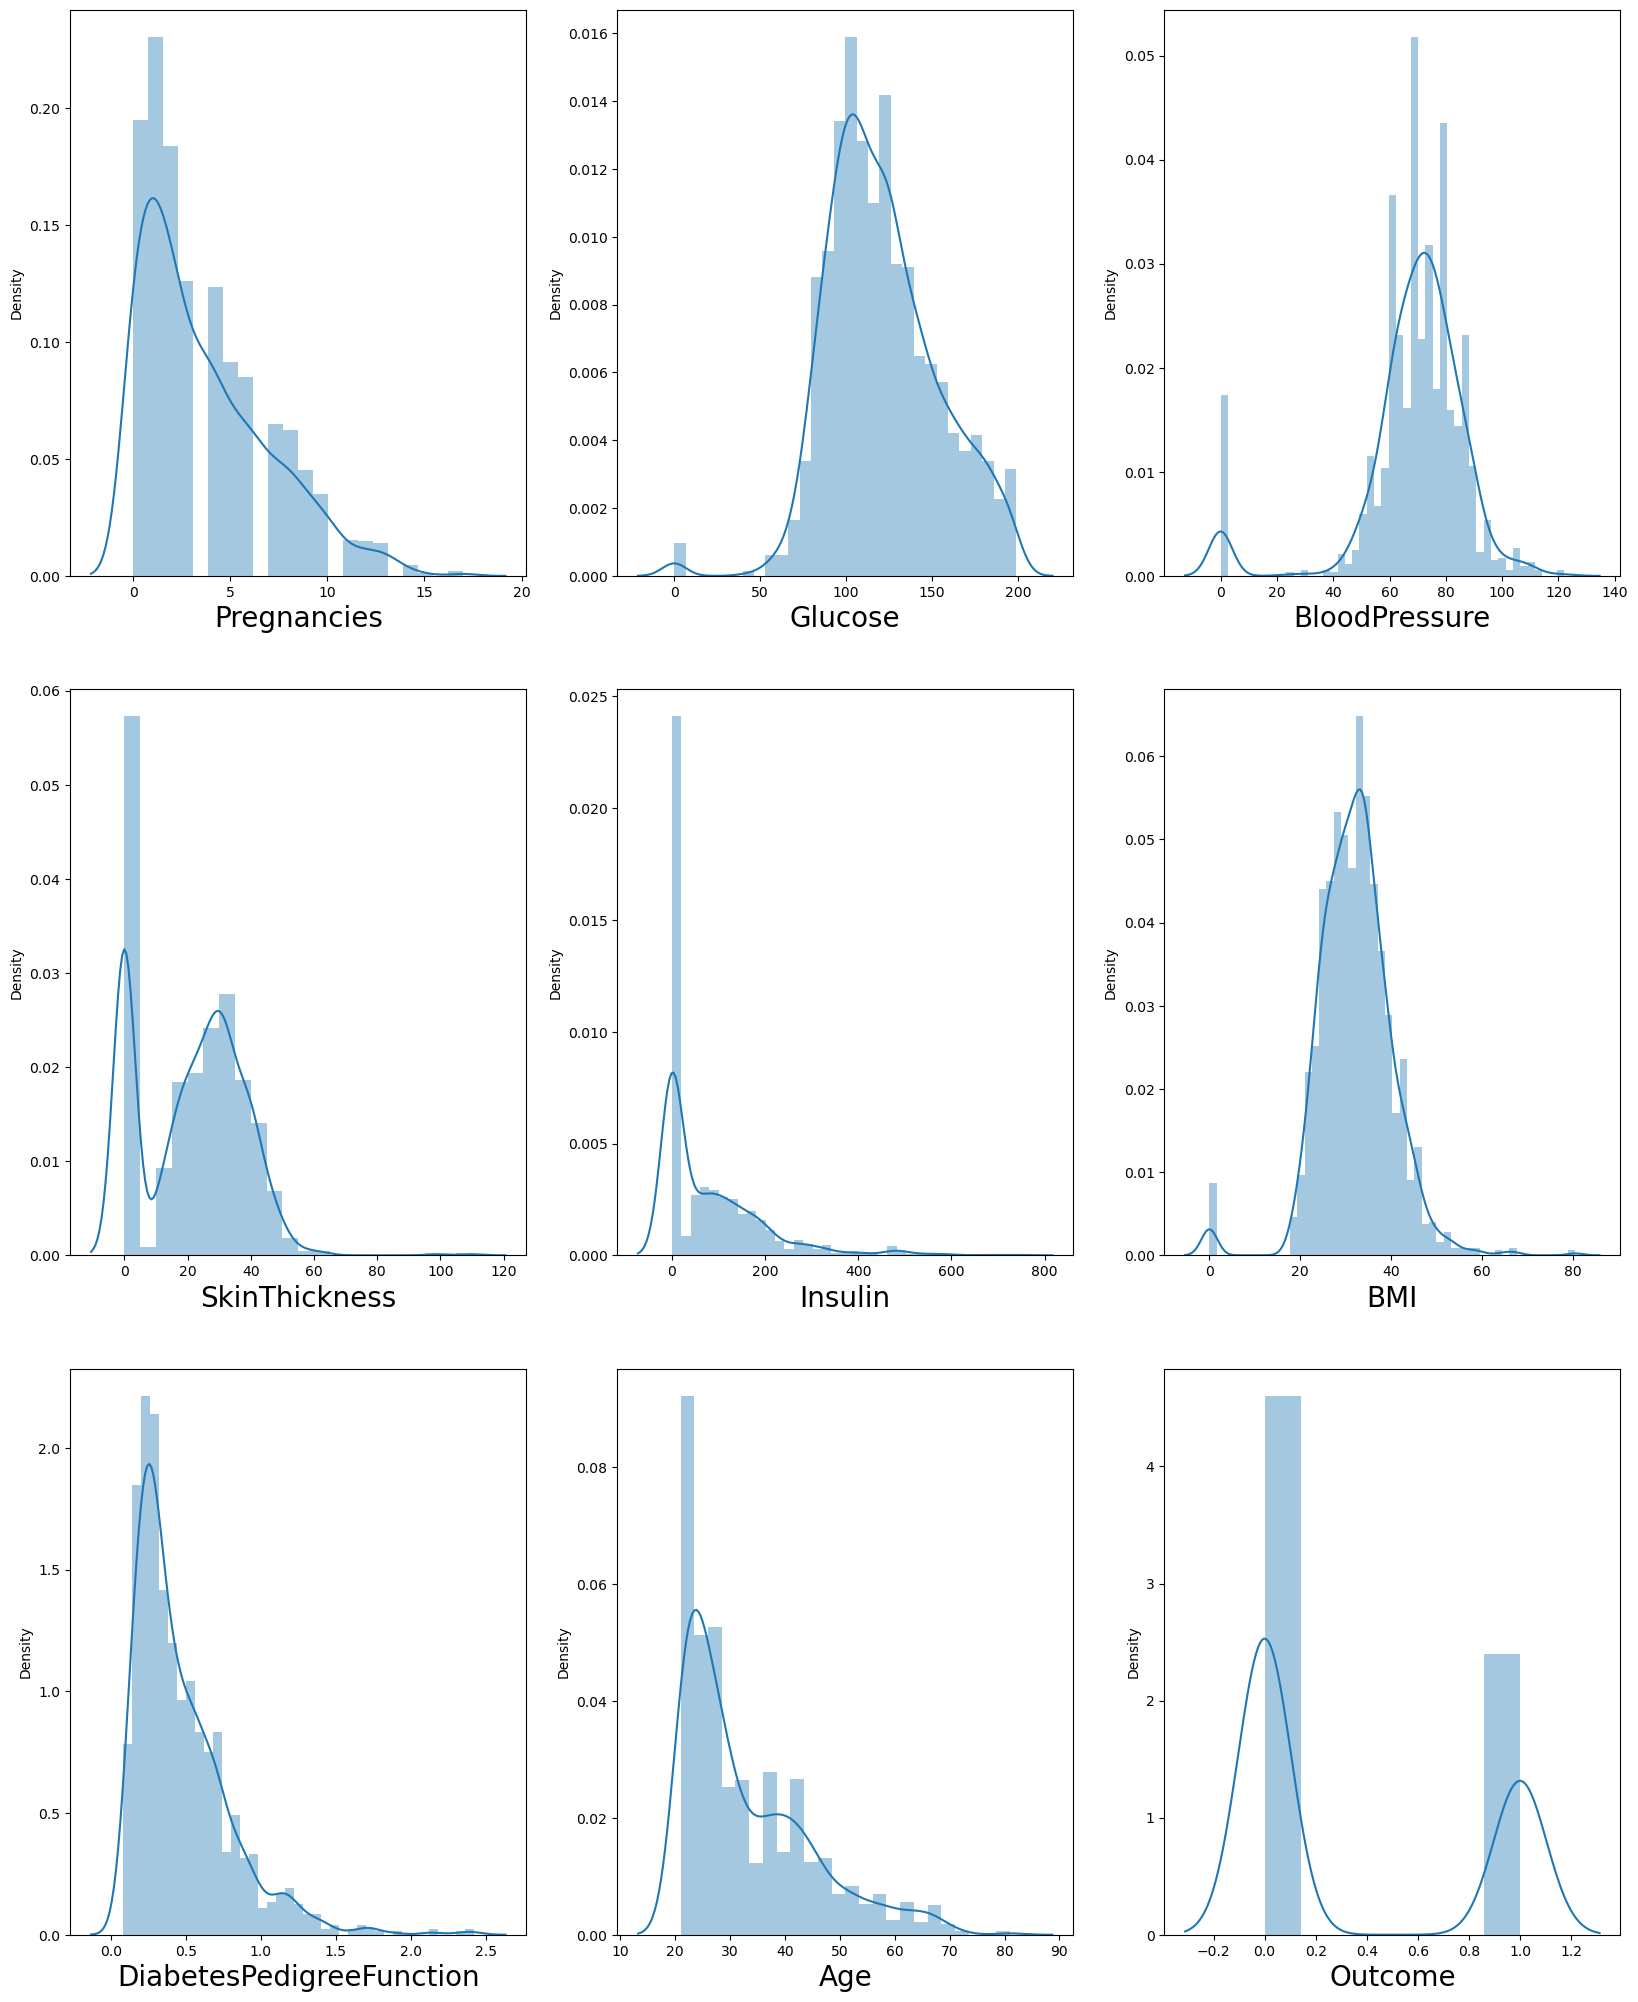

In [4]:
# let's see how data is distributed for every column
plt.figure(figsize=(20,25), facecolor='white')
plotnumber = 1

for column in data:
    if plotnumber<=9 :     # as there are 9 columns in the data
        ax = plt.subplot(3,3,plotnumber)
        sns.distplot(data[column])
        plt.xlabel(column,fontsize=20)
        #plt.ylabel('Salary',fontsize=20)
    plotnumber+=1
plt.show()

In [5]:
### Split X and Y
X = data.drop(columns = ['Outcome']) # Independent variables
y = data['Outcome'] # Dependent or target varaible.

In [6]:
## scaling the data
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)

In [7]:
## splitting the training and testing data
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,random_state=42)

In [8]:
## taking optimal k to determine how many nearest neighbors  to create

# create a list to store the error values for each k
error_rate = []

# Will take some time
for i in range(1,11):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

In [9]:
error_rate

[np.float64(0.032),
 np.float64(0.116),
 np.float64(0.158),
 np.float64(0.2),
 np.float64(0.204),
 np.float64(0.218),
 np.float64(0.204),
 np.float64(0.224),
 np.float64(0.196),
 np.float64(0.194)]

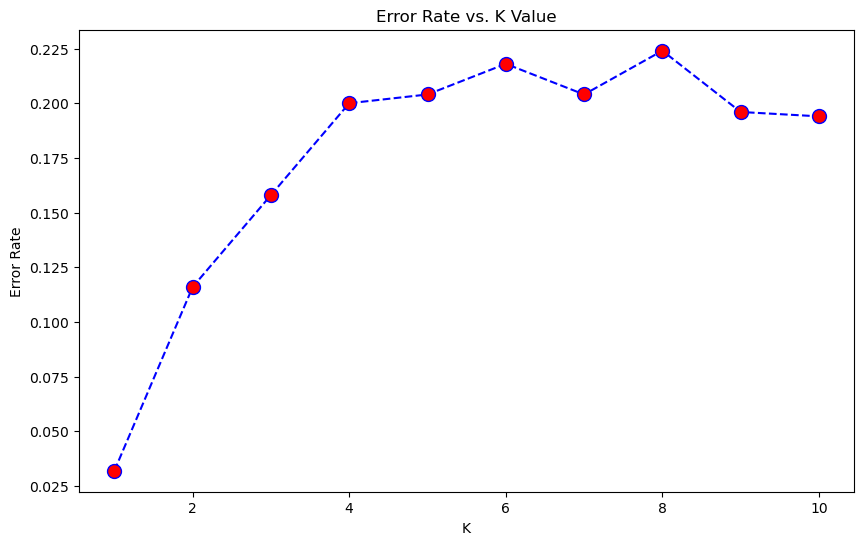

In [10]:
# Lets plot the k-value and error rate

plt.figure(figsize=(10,6))
plt.plot(range(1,11),error_rate,color='blue', linestyle='dashed', 
         marker='o',markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

In [14]:
## This is reference code donot run this on current dataset.
## Error calculation for regression task
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

rmse_val = [] #create list to store rmse values for different k
for K in range(1,20):
    
    model = KNeighborsRegressor(n_neighbors = K)

    model.fit(X_train, y_train)  #fit the model
    pred=model.predict(X_test) #make prediction on test set
    error = np.sqrt(mean_squared_error(y_test,pred)) #calculate rmse
    rmse_val.append(error) #store rmse values
    print('RMSE value for k= ' , K , 'is:', error)

RMSE value for k=  1 is: 0.17888543819998318
RMSE value for k=  2 is: 0.2519920633670831
RMSE value for k=  3 is: 0.31552425509864623
RMSE value for k=  4 is: 0.34767082132384936
RMSE value for k=  5 is: 0.36463680560250633
RMSE value for k=  6 is: 0.3717077705223105
RMSE value for k=  7 is: 0.37661218075611624
RMSE value for k=  8 is: 0.37691179339468805
RMSE value for k=  9 is: 0.3769926481910801
RMSE value for k=  10 is: 0.37759766948433354
RMSE value for k=  11 is: 0.37564269993775856
RMSE value for k=  12 is: 0.3752221564175904
RMSE value for k=  13 is: 0.3720723986302736
RMSE value for k=  14 is: 0.37349698793966196
RMSE value for k=  15 is: 0.37649848752831816
RMSE value for k=  16 is: 0.3768599706787655
RMSE value for k=  17 is: 0.3761119615386577
RMSE value for k=  18 is: 0.3749238605831428
RMSE value for k=  19 is: 0.37463925399925607


In [12]:
# let's fit the data into KNN model and see how well it performs:
knn1 = KNeighborsClassifier(n_neighbors=5)
knn1.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [13]:
# Predict 
y_pred = knn1.predict(X_test)

In [14]:
# Checking Accuracy score
print("The accuracy score is : ", accuracy_score(y_test,y_pred))

The accuracy score is :  0.796


In [15]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       320
           1       0.73      0.68      0.71       180

    accuracy                           0.80       500
   macro avg       0.78      0.77      0.78       500
weighted avg       0.79      0.80      0.79       500



In [19]:
recall1=recall_score(y_test,y_pred)
recall1

0.6833333333333333

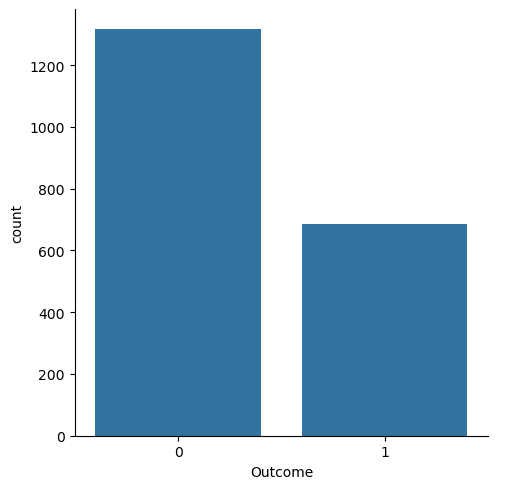

In [20]:
## checking the balance of traget
sns.catplot(x='Outcome',data=data,kind='count') # Imbalanced dataset

In [21]:
data.Outcome.value_counts()

Outcome
0    1316
1     684
Name: count, dtype: int64

In [23]:
df=sns.load_dataset('iris')

In [24]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


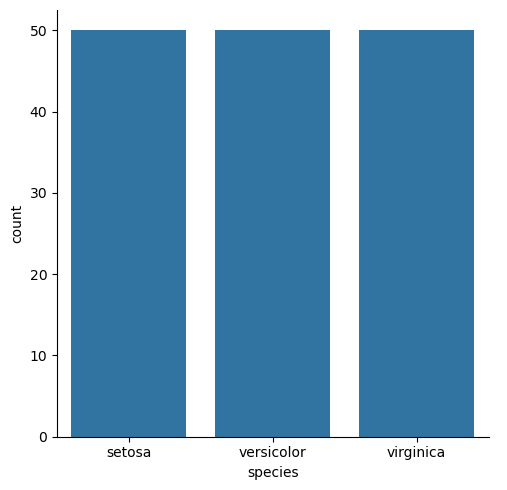

In [25]:
sns.catplot(x='species',data=df,kind='count') # Balanced dataset

In [26]:
df.species.value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [27]:
!pip install imblearn

# After installing library restart the kernel.

In [28]:
conda install --user glemaitre imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


usage: conda-script.py [-h] [-v] [--no-plugins] [-V] COMMAND ...
conda-script.py: error: unrecognized arguments: --user


In [29]:
!pip install -U imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
  Attempting uninstall: imbalanced-learn
   ---------------------------------------- 0/2 [sklearn-compat]
    Found existing installation: imbalanced-learn 0.14.0
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
    Uninstalling imbalanced-learn-0.14.0:
   -------------------- ------------------- 1/2 [imbalanced-learn]
      Successfully uninstalled imbalanced-learn-0.14.0
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---

In [30]:
# Apply SMOTE to balance the data
from imblearn.over_sampling import SMOTE
smote = SMOTE() ## object creation

In [31]:
y_train.value_counts()

Outcome
0    996
1    504
Name: count, dtype: int64

In [32]:
X_train_smote, y_train_smote = smote.fit_resample(X_train.astype('float'),
                                                  y_train)

In [33]:
y=np.array(y_train_smote)

In [34]:
y

array([0, 0, 0, ..., 1, 1, 1], shape=(1992,))

<Axes: ylabel='count'>

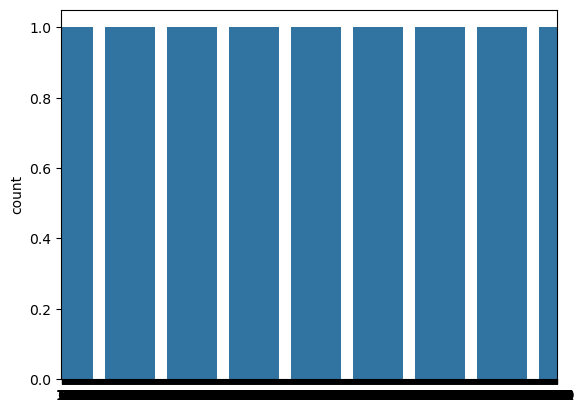

In [35]:
sns.countplot(y_train_smote)

<Axes: ylabel='count'>

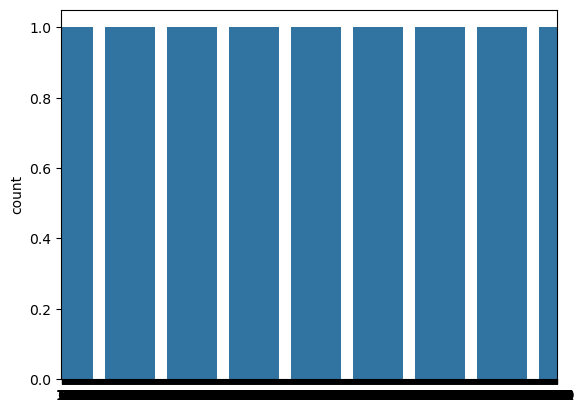

In [36]:
sns.countplot(y)

In [37]:
from collections import Counter
print("Actual Classes",Counter(y_train))
print("SMOTE Classes",Counter(y_train_smote))

Actual Classes Counter({0: 996, 1: 504})
SMOTE Classes Counter({0: 996, 1: 996})


In [38]:
knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train_smote, y_train_smote)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [39]:
# Predict the output for X_test
y_pred = knn2.predict(X_test)

In [40]:
print("The accuracy score is : ", accuracy_score(y_test,y_pred))

The accuracy score is :  0.824


In [41]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.81      0.86       320
           1       0.72      0.84      0.78       180

    accuracy                           0.82       500
   macro avg       0.81      0.83      0.82       500
weighted avg       0.84      0.82      0.83       500



In [16]:
newpred=knn.predict([[0.52,0.39,0.45,0.12,0.76,0.25,0.96,0.11]])
if newpred[0]==0.64:
    print('no diabetes')
else:
    print('diabetes')

diabetes


In [18]:
knn1.predict([[0.52,0.39,0.45,0.12,0.76,0.25,0.96,0.11]])

array([1])